In [1]:
import pandas as pd 
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [2]:
dataset = sns.get_dataset_names()
dataset

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [3]:
diam_df = sns.load_dataset('diamonds')
diam_df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [4]:
diam_df['cut'].unique()

['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Categories (5, object): ['Ideal', 'Premium', 'Very Good', 'Good', 'Fair']

In [5]:
le = LabelEncoder()
encoded_cut = le.fit_transform(diam_df['cut'])
encoded_cut

array([2, 3, 1, ..., 4, 3, 2], shape=(53940,))

In [6]:
print('original', diam_df['cut'])
print('encoded', encoded_cut)
print('classes', le.classes_)

original 0            Ideal
1          Premium
2             Good
3          Premium
4             Good
           ...    
53935        Ideal
53936         Good
53937    Very Good
53938      Premium
53939        Ideal
Name: cut, Length: 53940, dtype: category
Categories (5, object): ['Ideal', 'Premium', 'Very Good', 'Good', 'Fair']
encoded [2 3 1 ... 4 3 2]
classes ['Fair' 'Good' 'Ideal' 'Premium' 'Very Good']


In [7]:
for i, cls in enumerate(le.classes_):
    print(f"{cls} -> {i}")

Fair -> 0
Good -> 1
Ideal -> 2
Premium -> 3
Very Good -> 4


In [8]:
diam_df['cut'] = encoded_cut
diam_df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,2,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,2,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,1,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,4,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,3,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [9]:
diam_df['clarity'].unique()

['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']
Categories (8, object): ['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1']

In [10]:
encoded_clarity = le.fit_transform(diam_df['clarity'])
encoded_clarity

array([3, 2, 4, ..., 2, 3, 3], shape=(53940,))

In [11]:
for i, cls in enumerate(le.classes_):
    print(f"{cls} -> {i}")

I1 -> 0
IF -> 1
SI1 -> 2
SI2 -> 3
VS1 -> 4
VS2 -> 5
VVS1 -> 6
VVS2 -> 7


In [12]:
diam_df['clarity'] = encoded_clarity
diam_df.head(30)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,2,E,3,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,E,2,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1,E,4,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3,I,5,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,J,3,63.3,58.0,335,4.34,4.35,2.75
5,0.24,4,J,7,62.8,57.0,336,3.94,3.96,2.48
6,0.24,4,I,6,62.3,57.0,336,3.95,3.98,2.47
7,0.26,4,H,2,61.9,55.0,337,4.07,4.11,2.53
8,0.22,0,E,5,65.1,61.0,337,3.87,3.78,2.49
9,0.23,4,H,4,59.4,61.0,338,4.00,4.05,2.39


<Axes: xlabel='price', ylabel='Count'>

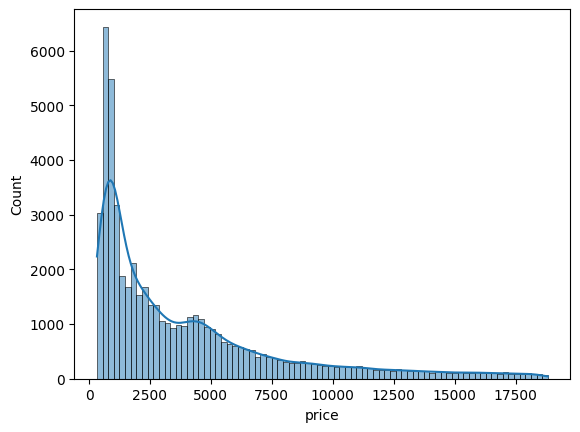

In [13]:
sns.histplot(diam_df['price'], kde=True)

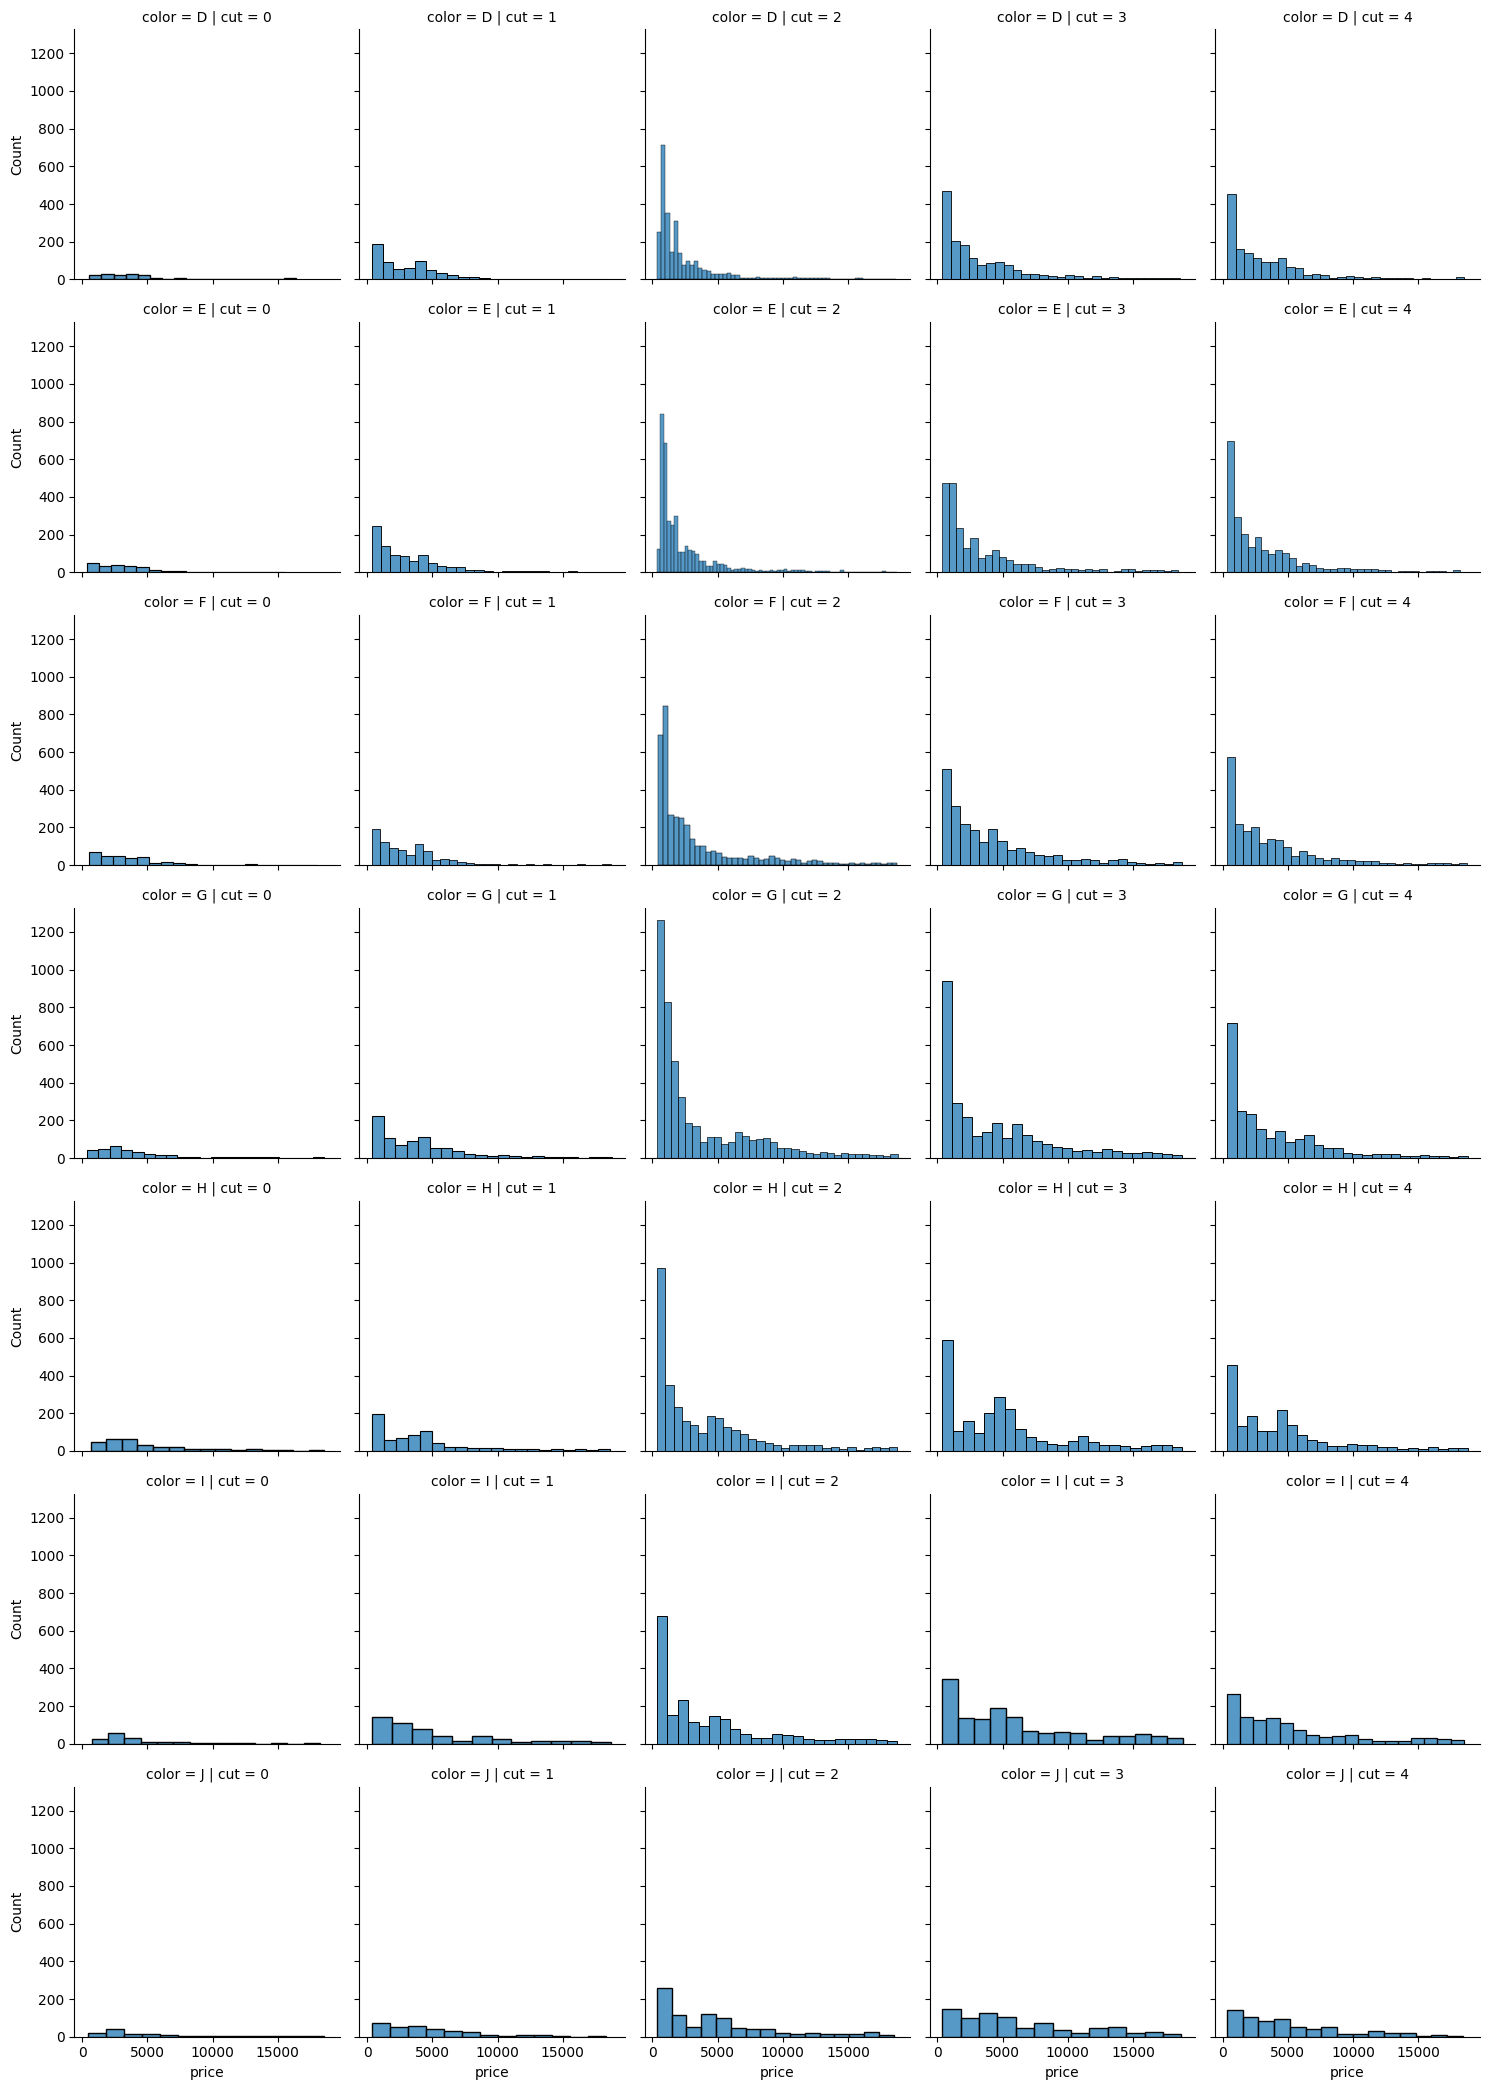

In [14]:
g = sns.FacetGrid(diam_df, col="cut", row="color")
g.map_dataframe(sns.histplot, x="price")


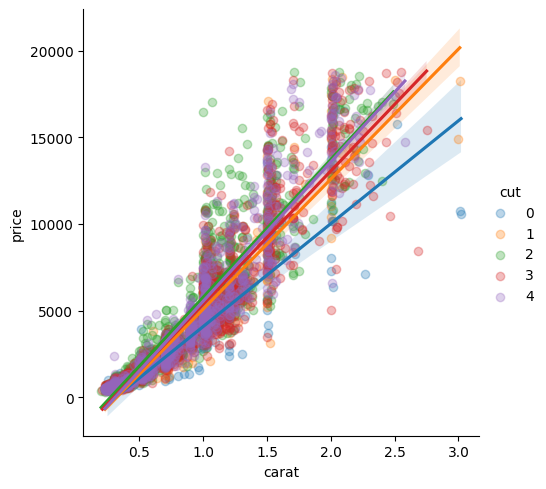

In [15]:
sns.lmplot(x="carat", y="price", data=diam_df.sample(5000), hue="cut", scatter_kws={'alpha':0.3})

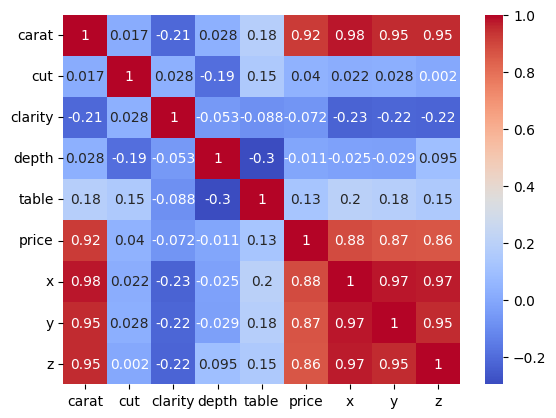

In [16]:
corr = diam_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

<Axes: xlabel='carat', ylabel='price'>

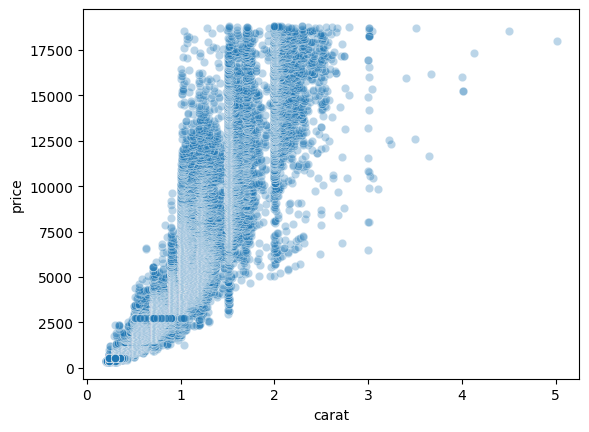

In [17]:
sns.scatterplot(x="carat", y="price", data=diam_df, alpha=0.3)